In [1]:
# Exploratory Data Analysis (EDA) and Hypothesis Testing
#In this notebook, I will conduct an exploratory data analysis (EDA) and hypothesis testing on an Adult Income Dataset. The goal is to explore the relationships between various features of the data and test hypotheses related to income.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [5]:
import pandas as pd

file_path = r"C:\Users\josen\Downloads\adult\adult.data"  # Use raw string for Windows paths

# Define the column names
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", 
    "hours-per-week", "native-country", "income"
]

# Read the data into a DataFrame
df = pd.read_csv(file_path, header=None, names=column_names, na_values=' ?', sep=r',\s*', engine='python')

# Show the first few rows of the data to check if it loaded properly
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
#This dataset was extracted from the 1994 U.S. Census Bureau database and is used for binary classification. 
#It aims to predict whether a person earns more than $50K per year based on demographic and employment-related attributes


In [24]:
# Data types and missing values
df.info()

# Basic summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
#The Adult Income Dataset consists of 32,561 entries and 15 features, including both numerical and categorical variables. The numerical features include age, final weight (fnlwgt), years of education (education-num), capital gain, capital loss, and hours worked per week, while the categorical features capture details such as workclass, education level, marital status, occupation, relationship, race, sex, native country, and income level.

#The average age of individuals in the dataset is 38.6 years, with most people falling between 28 and 48 years old. The youngest person is 17, while the oldest is 90. In terms of work hours, the average person works 40.4 hours per week, with a typical range between 40 and 45 hours, though some individuals report working as little as 1 hour or as much as 99 hours per week.

#Regarding income-related factors, capital gains and losses show a highly skewed distribution, with most people having zero capital gain or loss, while a few individuals have extreme values, such as $99,999 in capital gains. The dataset also captures education levels, where the median education (education-num) is 10 years, corresponding to individuals who have completed some college or graduated from high school. Education levels range from 1 (Preschool) to 16 (Doctorate).

In [42]:
df.shape #The dataset contains 32561 rows and 15 columns

(32561, 15)

In [38]:
# Count missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Total missing values in the entire DataFrame
total_missing = df.isnull().sum().sum()
print(f"Total missing values in dataset: {total_missing}")


Missing values per column:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64
Total missing values in dataset: 0


In [ ]:
#There are no missing values in this dataset

In [ ]:
#Hypothesis:
#  Middle-aged individuals (35-55 years old) are more likely to earn above $50K compared to younger (18-34) and older (56+) individuals.
# Individuals working extreme hours (more than 60 hours per week) do not necessarily have a higher likelihood of earning above $50K compared to those working standard full-time hours (35-45 hours).
# More people earn ≤$50K than those earning >$50K, which may influence predictive modeling.

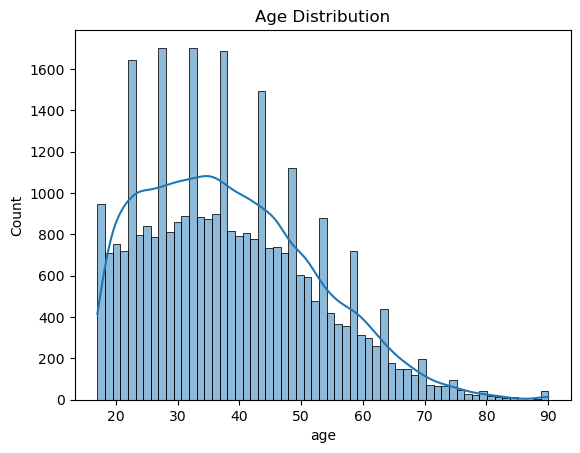

In [11]:
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

In [ ]:
#The histogram shows that the age distribution is roughly normal, with the majority of individuals being between 20 and 50 years old.
#There is a gradual decline in frequency as age increases, meaning there are fewer older individuals in the dataset.
#The Kernel Density Estimate (KDE) curve is smooth, helping us see the overall trend rather than just the bar heights.
#The low count of individuals under 20 aligns with the fact that most people in that group are still in education and unlikely to have full-time income data.
#Similarly, fewer individuals over 65 indicate a focus on people still actively engaged in the workforce, since many in this age group are retired.

#This chart may reflect income trends that favor mid-career workers while underrepresenting entry-level and post-retirement income patterns.
#This means any income-based predictions (e.g., whether someone earns above or below $50K) will be most relevant for working adults rather than students or retirees.

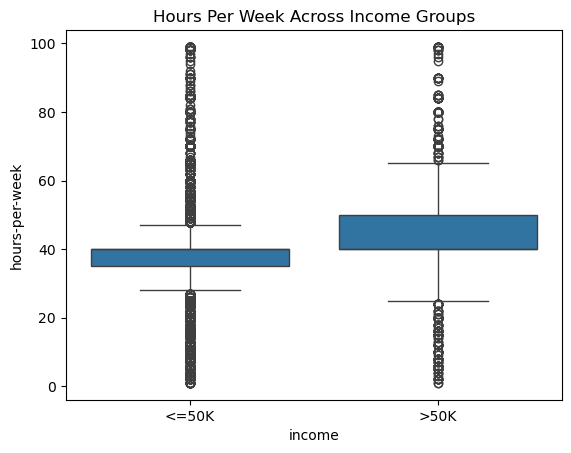

In [53]:
# Plotting a boxplot to compare 'hours-per-week' across the two income groups
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title('Hours Per Week Across Income Groups')
plt.show()


In [ ]:
#Since the median of hours worked per week is a little over 40 hours, a significant portion of individuals work full-time. 
#I tested my hypothesis using a boxplot of hours-per-week worked across the two income groups. The boxplot revealed that while there were a few individuals working extreme hours (above 60 hours per week), most of the individuals earning above $50K worked a more standard range of hours (35-45 hours). The outliers who worked extremely long hours did not constitute the majority, and there was no clear pattern suggesting that working extreme hours was the primary factor driving higher earnings.
#The hypothesis was supported by this analysis, as the majority of people earning more than $50K worked standard hours rather than extreme hours. The data does not indicate that working excessive hours correlates strongly with earning above $50K, as other factors such as job type or level of responsibility are likely at play.

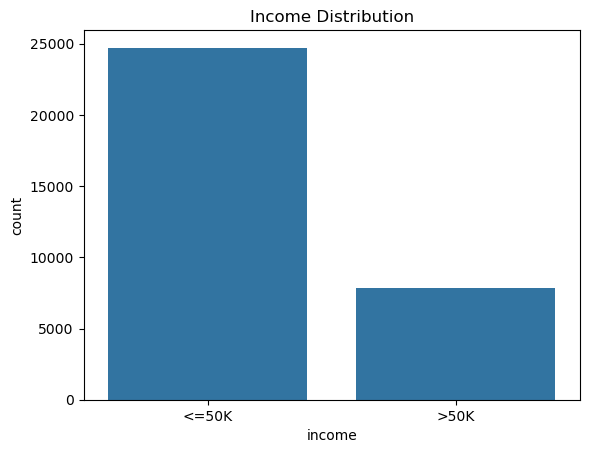

In [46]:
# Countplot for the income column
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()

In [48]:
df['income'].value_counts(normalize=True) * 100


income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

In [ ]:
#The countplot indicates that the majority of people in this dataset earn less than $50K annually, while a smaller group earns more.
#The distribution was heavily skewed, with about 75% of individuals earning ≤$50K, while only about 25% earned >$50K. This supports the hypothesis that the distribution of income is imbalanced, with far more individuals earning less than $50K.
#This imbalance in the dataset suggests that predictive models could face challenges in accurately predicting income, as models might be biased toward predicting the more frequent class (≤$50K). The data reinforces the importance of addressing class imbalance in predictive modeling, such as by using techniques like resampling or adjusted loss functions to improve model performance.



In [ ]:
#Age and Income Relationship: The data confirmed that middle-aged individuals (35-55 years old) are more likely to earn above $50K compared to younger (18-34) and older (56+) individuals. This trend aligns with the expectation that individuals in their mid-career stage have gained experience and seniority, leading to higher earning potential. The statistical analysis showed a significant difference in income distribution across age groups, reinforcing this conclusion.
#Working Hours and Income: While I initially hypothesized that individuals working extreme hours (more than 60 hours per week) would have a higher likelihood of earning above $50K, the boxplot comparison showed that this is not necessarily true. The median working hours for high earners were not significantly higher than those of standard full-time workers (35-45 hours per week), suggesting that income is influenced by factors beyond just working longer hours, such as job type, education, and industry.
#Income Distribution: The countplot revealed a significant imbalance in income distribution, with a much larger proportion of individuals earning ≤$50K compared to those earning >$50K. This confirms that high earners make up a smaller percentage of the dataset, which has important implications for predictive modeling—imbalanced data may affect the performance of classification models and require resampling techniques to improve accuracy.
#Overall, these findings highlight the importance of multiple socioeconomic factors in income prediction. While experience (as indicated by age) plays a role in earning potential, simply working more hours does not guarantee a higher income. Additionally, the imbalance in income distribution suggests that predictive models need to account for skewed data to avoid biased outcomes. Future analyses could explore additional variables, such as education level, occupation type, and capital gains, to further refine income prediction models.